# 9. Autoencoders

En este notebook aprenderás los fundamentos de los autoencoders, incluyendo autoencoders simples, denoising y variacionales (VAE), con ejemplos prácticos en TensorFlow/Keras.

## Objetivo
- Comprender la teoría y arquitectura de los autoencoders.
- Implementar un autoencoder simple, un denoising autoencoder y un VAE.
- Visualizar reconstrucciones y el espacio latente.
- Aplicar buenas prácticas para entrenamiento eficiente.

## Prerequisitos

> 📌 **Prerequisitos:** Haber completado los notebooks [04 (MLP)](./04_redes_neuronales_capa_densa.ipynb) y [08 (GANs)](./08_gans.ipynb).

- Conceptos de redes neuronales y modelos generativos.

## 1. Introducción teórica

Un autoencoder comprime datos en una representación de menor dimensión y luego los reconstruye.

| Tipo | Uso principal | Característica |
|------|---------------|----------------|
| **Simple** | Reducción de dimensionalidad | Comprime y reconstruye |
| **Denoising** | Eliminación de ruido | Entrena con datos ruidosos |
| **Variacional (VAE)** | Generación de datos | Espacio latente continuo y muestreable |

## 2. Importación de librerías

In [7]:
# === Reproducibilidad ===
import random
import numpy as np
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers
tf.random.set_seed(SEED)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 3. Autoencoder simple

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
X_train_flat = X_train.reshape(-1, 28*28)
X_test_flat = X_test.reshape(-1, 28*28)

encoding_dim = 32
input_img = keras.Input(shape=(784,))
encoded = keras.layers.Dense(128, activation='relu')(input_img)
encoded = keras.layers.Dense(encoding_dim, activation='relu')(encoded)
decoded = keras.layers.Dense(128, activation='relu')(encoded)
decoded = keras.layers.Dense(784, activation='sigmoid')(decoded)

autoencoder = keras.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(X_train_flat, X_train_flat, epochs=20, batch_size=256,
                shuffle=True, validation_data=(X_test_flat, X_test_flat), verbose=1)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0570 - val_loss: 0.0310
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0248 - val_loss: 0.0200
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0186 - val_loss: 0.0166
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0160 - val_loss: 0.0146
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0143 - val_loss: 0.0132
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0131 - val_loss: 0.0123
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0123 - val_loss: 0.0117
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0117 - val_loss: 0.0112
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0113 - val_loss: 0.0108
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0109 - val_loss: 0.0105
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0106 - val_loss: 0.0102
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

### Visualización de reconstrucciones

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


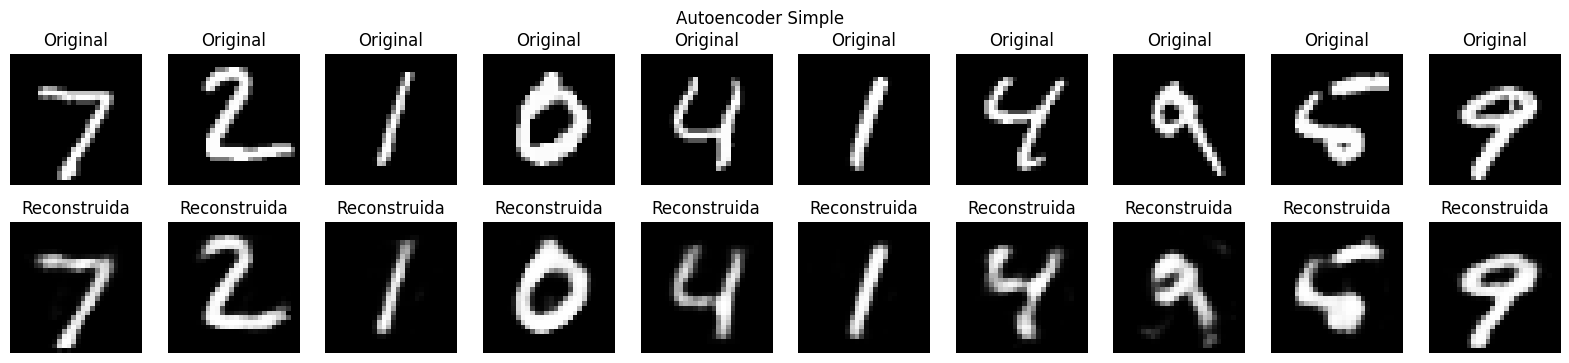

In [3]:
decoded_imgs = autoencoder.predict(X_test_flat)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title('Original')
    plt.axis('off')
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title('Reconstruida')
    plt.axis('off')
plt.suptitle('Autoencoder Simple')
plt.show()

## 4. Denoising Autoencoder

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0641 - val_loss: 0.0401
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0356 - val_loss: 0.0314
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0301 - val_loss: 0.0283
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0276 - val_loss: 0.0263
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0258 - val_loss: 0.0249
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0246 - val_loss: 0.0239
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0238 - val_loss: 0.0232
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0231 - val_loss: 0.0226
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0226 - val_loss: 0.0222
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0222 - val_loss: 0.0217
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


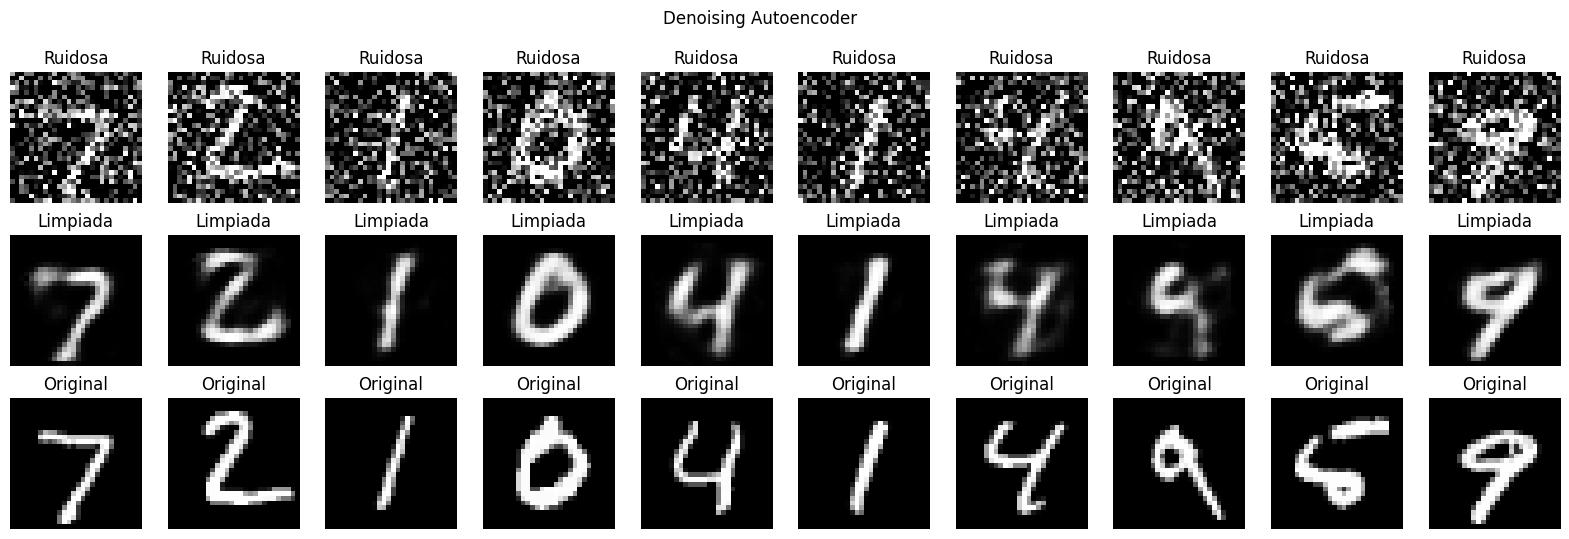

In [4]:
noise_factor = 0.5
X_train_noisy = X_train_flat + noise_factor * np.random.normal(0, 1, X_train_flat.shape)
X_test_noisy = X_test_flat + noise_factor * np.random.normal(0, 1, X_test_flat.shape)
X_train_noisy = np.clip(X_train_noisy, 0., 1.)
X_test_noisy = np.clip(X_test_noisy, 0., 1.)

denoising_ae = keras.models.clone_model(autoencoder)
denoising_ae.compile(optimizer='adam', loss='mse')
denoising_ae.fit(X_train_noisy, X_train_flat, epochs=10, batch_size=256,
                 shuffle=True, validation_data=(X_test_noisy, X_test_flat), verbose=1)

decoded_noisy = denoising_ae.predict(X_test_noisy)

plt.figure(figsize=(20, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(X_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title('Ruidosa')
    plt.axis('off')
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(decoded_noisy[i].reshape(28, 28), cmap='gray')
    plt.title('Limpiada')
    plt.axis('off')
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(X_test[i], cmap='gray')
    plt.title('Original')
    plt.axis('off')
plt.suptitle('Denoising Autoencoder')
plt.show()

## 5. Variational Autoencoder (VAE)

El VAE aprende un espacio latente **continuo y muestreable**, permitiendo generar nuevos datos interpolando en el espacio latente.

In [8]:
class VAE(keras.Model):
    def __init__(self, latent_dim, **kwargs):
        super().__init__(**kwargs)
        self.latent_dim = latent_dim
        
        # Encoder
        encoder_inputs = keras.Input(shape=(784,))
        h = layers.Dense(256, activation='relu')(encoder_inputs)
        self.z_mean = layers.Dense(latent_dim, name="z_mean")(h)
        self.z_log_var = layers.Dense(latent_dim, name="z_log_var")(h)
        
        # Sampler (Reparametrización interna)
        def sampling(args):
            z_mean, z_log_var = args
            epsilon = tf.random.normal(shape=tf.shape(z_mean))
            return z_mean + tf.exp(0.5 * z_log_var) * epsilon
        
        z = layers.Lambda(sampling)([self.z_mean, self.z_log_var])
        self.encoder = keras.Model(encoder_inputs, [self.z_mean, self.z_log_var, z], name="encoder")

        # Decoder
        latent_inputs = keras.Input(shape=(latent_dim,))
        h_dec = layers.Dense(256, activation='relu')(latent_inputs)
        decoder_outputs = layers.Dense(784, activation='sigmoid')(h_dec)
        self.decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")

        # Métricas para monitorear
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")

    def train_step(self, data):
        with tf.GradientTape() as tape:
            # Forward pass
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            
            # Cálculo de pérdidas (usando Keras Ops para compatibilidad)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(keras.losses.binary_crossentropy(data, reconstruction), axis=-1)
            ) * 784
            
            kl_loss = -0.5 * tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=-1
            )
            total_loss = tf.reduce_mean(reconstruction_loss + kl_loss)

        # Gradientes y optimización
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        
        self.total_loss_tracker.update_state(total_loss)
        return {"loss": self.total_loss_tracker.result()}

# Uso:
vae = VAE(latent_dim=2)
vae.compile(optimizer='adam')
vae.fit(X_train_flat, epochs=15, batch_size=256)

Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 53744.0430
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 43744.5430
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 41666.3008
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - loss: 40658.9023
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 39997.0625
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 39513.8945
Epoch 7/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 39132.8984
Epoch 8/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - loss: 38826.3398
Epoch 9/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - loss: 38579.2891
Epoch 10/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 38371.7773
Epoch 11/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 38197.6211
Epoch 12/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 38046.6758
Epoch 13/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 37906.2070
Epoch 14/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step -

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


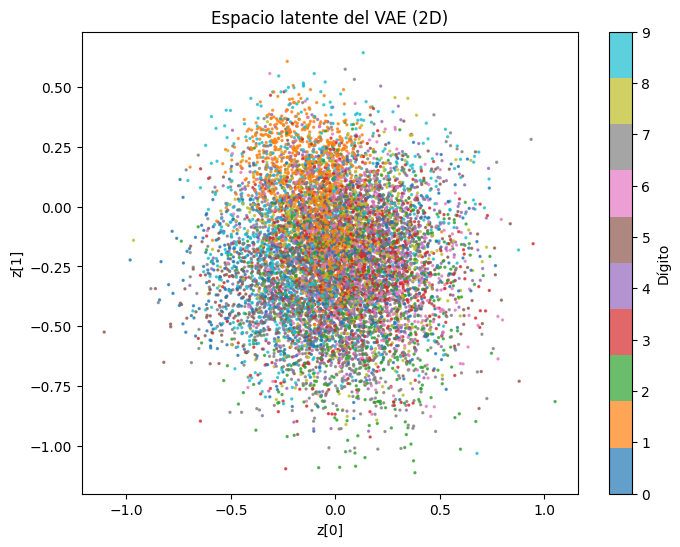

In [9]:
# Visualizar espacio latente
encoder = keras.Model(encoder_inputs, z_mean)
z_test = encoder.predict(X_test_flat)

plt.figure(figsize=(8, 6))
plt.scatter(z_test[:, 0], z_test[:, 1], c=y_test, cmap='tab10', s=2, alpha=0.7)
plt.colorbar(label='Dígito')
plt.title('Espacio latente del VAE (2D)')
plt.xlabel('z[0]')
plt.ylabel('z[1]')
plt.show()

### Recomendaciones prácticas

| Aspecto | Recomendación |
|---------|---------------|
| **Espacio latente** | Ajusta dimensión según la compresión deseada |
| **Regularización** | Usa Dropout, L1/L2 para evitar sobreajuste |
| **Denoising** | Mejora la robustez y las representaciones |
| **VAE** | Espacio latente continuo; ideal para generación |
| **Visualización** | Siempre visualiza reconstrucciones |

## 6. Discusión y Conclusiones

- Implementamos 3 tipos de autoencoders: simple, denoising y variacional.
- El VAE permite generar nuevos datos y explorar el espacio latente.
- Los denoising autoencoders son útiles para limpiar datos.
- En el siguiente notebook veremos técnicas de clustering y reducción de dimensionalidad.

## 7. Ejercicios Propuestos

1. **Ejercicio 1:** Cambia `encoding_dim` a 8, 16 y 64. ¿Cómo afecta la calidad de reconstrucción?

2. **Ejercicio 2:** Usa el VAE para generar nuevos dígitos muestreando puntos del espacio latente.

3. **Ejercicio 3:** Implementa un autoencoder convolucional (usando Conv2D y Conv2DTranspose).

4. **Ejercicio 4 (Avanzado):** Usa un VAE condicional (CVAE) que genere dígitos específicos.

### Resolución de Ejercicios Propuestos

Para culminar este estudio sobre Autoencoders, se han seleccionado el **Ejercicio 3** y el **Ejercicio 4**, los cuales abordan las arquitecturas más utilizadas en la visión computacional y el modelado generativo controlado:

1.  **Ejercicio 3 (Autoencoder Convolucional):** Superaremos la limitación espacial anatómica de las redes Densas. Las imágenes ya no serán vectores aplanados de 784 píxeles, sino matrices 2D de `(28, 28, 1)`. Reemplazaremos el modelo anterior por capas `Conv2D` y `MaxPooling2D` para el Encoder (extracción de características) y `Conv2DTranspose` (o `UpSampling2D`) para el Decoder (reconstrucción espacial).
2.  **Ejercicio 4 (VAE Condicional - CVAE):** Llevaremos nuestro Autoencoder Variacional al siguiente nivel inyectándole de forma condicionada las etiquetas de los dígitos. Esto nos permitirá explorar el espacio latente y pedirle a la red de modo determinista que dibuje el número exacto que deseamos.


#### Ejercicio 3: Implementación de Autoencoder Convolucional
Primero, redimensionaremos nuestro conjunto de datos que previamente habíamos aplanado (`X_train_flat`) para devolverle su geometría espacial bidimensional. Luego, ensamblaremos el autoencoder usando filtros de convolución.

In [10]:
# 1. Recuperamos la forma 2D original de las imágenes (28x28x1)
# Usaremos los mismos X_train_flat y X_test_flat que ya estaban normalizados entre 0 y 1.
X_train_conv = X_train_flat.reshape(-1, 28, 28, 1)
X_test_conv = X_test_flat.reshape(-1, 28, 28, 1)

# 2. ENCODER Convolucional
input_img = keras.Input(shape=(28, 28, 1), name="conv_input")
# Extrae features y reduce tamaño espacial
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
# Salida del Encoder: tamaño (7, 7, 8)
encoded = layers.MaxPooling2D((2, 2), padding='same', name="encoded_conv")(x)

# 3. DECODER Convolucional
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
# Reconstrucción final: tamaño (28, 28, 1) finaliza con sigmoid para [0,1]
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded_conv")(x)

# 4. Compilación del modelo
autoencoder_conv = keras.Model(input_img, decoded, name="Autoencoder_Convolucional")
autoencoder_conv.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder_conv.summary()

# 5. Entrenamiento
print("\nIniciando entrenamiento del Autoencoder Convolucional...")
history_conv = autoencoder_conv.fit(
    X_train_conv, X_train_conv,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test_conv, X_test_conv)
)

Model: "Autoencoder_Convolucional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_input (InputLayer)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded_conv (MaxPooling2D)     │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded_conv (Conv2D)           │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,217 (12.57 KB)

 Trainable params: 3,217 (12.57 KB)

 Non-trainable params: 0 (0.00 B)


Iniciando entrenamiento del Autoencoder Convolucional...
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 167ms/step - loss: 0.1425 - val_loss: 0.0892
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 94s 201ms/step - loss: 0.0855 - val_loss: 0.0814
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 119s 150ms/step - loss: 0.0806 - val_loss: 0.0783
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 173ms/step - loss: 0.0783 - val_loss: 0.0768
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 85s 177ms/step - loss: 0.0769 - val_loss: 0.0756
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 135s 160ms/step - loss: 0.0759 - val_loss: 0.0747
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 170ms/step - loss: 0.0751 - val_loss: 0.0740
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 172ms/step - loss: 0.0744 - val_loss: 0.0734
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 78s 166ms/step - loss: 0.0739 - val_loss: 0.0729
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 179ms/step - loss: 0.0735 - val_loss: 0.0725


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


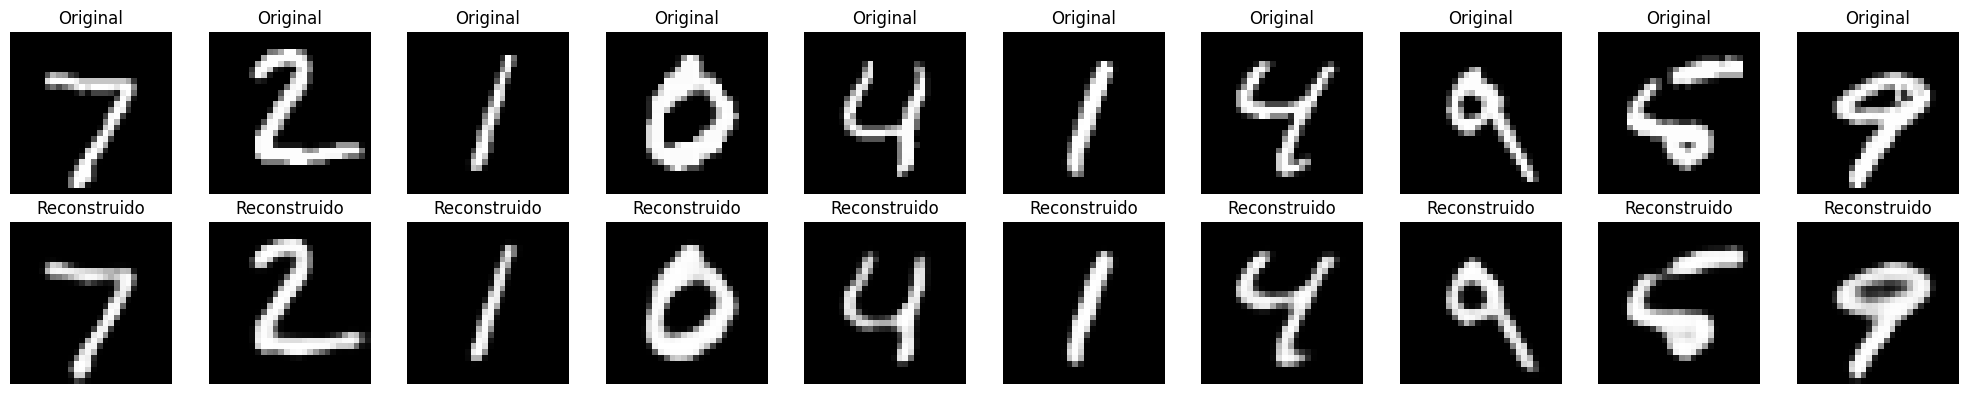

In [12]:
# Tomamos las primeras 10 imágenes del conjunto de test
n = 10
# Hacemos que el Autoencoder Convolucional las intente reconstruir
decoded_imgs_conv = autoencoder_conv.predict(X_test_conv[:n])

plt.figure(figsize=(20, 4))
for i in range(n):
    # Mostrar la imagen original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test_conv[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Mostrar la reconstrucción convolucional
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs_conv[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstruido")
    plt.axis("off")

plt.tight_layout()
plt.show()

#### Ejercicio 4 (Avanzado): Autoencoder Variacional Condicional (CVAE)
A diferencia de un VAE estándar donde el Decoder "imagina" de forma incontrolable dependiendo del punto aleatorio que caiga en su espacio latente normal, un **CVAE** recibe instrucciones explícitas. Lograremos esto "inyectando" el **One-Hot Encoding** de la clase (los dígitos del 0 al 9) en dos puntos críticos:
1. En el **Encoder**, concatenando la imagen aplanada con su respectiva etiqueta. Esto entrena al espacio latente a aprender el "estilo de escritura" desenredado del dígito real.
2. En el **Decoder**, concatenando la muestra latente (matriz gaussiana) con la misma etiqueta, para darle la orden de qué número dibujar con ese estilo.

In [11]:
# 1. Preparación de Etiquetas (Condition) en One-Hot Encoding
num_classes = 10

y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

# 2. ENCODER Condicional (CVAE)
latent_dim = 2

# Definición de Entradas (Imagen Aplanada + Condición)
encoder_inputs = keras.Input(shape=(784,), name="cvae_img_input")
condition_inputs = keras.Input(shape=(num_classes,), name="cvae_cond_input")

# Concatenamos la imagen aplanada y la condición
x_concat = layers.Concatenate()([encoder_inputs, condition_inputs])
x = layers.Dense(512, activation='relu')(x_concat)
x = layers.Dense(256, activation='relu')(x)

# Capas Estadísticas
z_mean = layers.Dense(latent_dim, name="z_mean_cond")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var_cond")(x)

# Función de Muestreo (Sampling)
def sampling(args):
    z_mean, z_log_var = args
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]
    epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling, output_shape=(latent_dim,))([z_mean, z_log_var])

encoder_cond = keras.Model([encoder_inputs, condition_inputs], [z_mean, z_log_var, z], name="encoder_cond")

# 3. DECODER Condicional
latent_inputs = keras.Input(shape=(latent_dim,), name="z_sampling_cond")

# Volvemos a inyectar la misma condición, esta vez al espacio latente
dec_concat = layers.Concatenate()([latent_inputs, condition_inputs])
x_dec = layers.Dense(256, activation='relu')(dec_concat)
x_dec = layers.Dense(512, activation='relu')(x_dec)
decoder_outputs = layers.Dense(784, activation='sigmoid')(x_dec)

decoder_cond = keras.Model([latent_inputs, condition_inputs], decoder_outputs, name="decoder_cond")

# 4. Clase customizada CVAE
class CVAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(CVAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        # data entra como tupla ((X_train, y_cond), Y_target)
        x_inputs, y_target = data
        images, conditions = x_inputs

        with tf.GradientTape() as tape:
            # Pasa la imagen y condición al Encoder
            z_mean, z_log_var, z = self.encoder([images, conditions])
            # Pasa la matriz latente extraída y la misma condición al Decoder
            reconstruction = self.decoder([z, conditions])
            
            # 1. Pérdida de Reconstrucción (BCE) por 784 píxeles
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(keras.losses.binary_crossentropy(y_target, reconstruction), axis=-1)
            ) * 784
            
            # 2. Pérdida de Divergencia KL (Regularización sobre distribución normal)
            kl_loss = -0.5 * tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=-1
            )
            total_loss = tf.reduce_mean(reconstruction_loss + kl_loss)

        # Aplicación de Gradientes
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        
        # Guardamos registros
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

cvae = CVAE(encoder_cond, decoder_cond)
cvae.compile(optimizer='adam')

# 5. Entrenamiento
print("\nIniciando entrenamiento del VAE Condicional...")
history_cvae = cvae.fit(
    x=[X_train_flat, y_train_cat], # Las dos entradas: Imágenes y sus Clases
    y=X_train_flat,                # El objetivo: Reconstruir la imagen
    epochs=15,
    batch_size=128
)


Iniciando entrenamiento del VAE Condicional...
Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 113ms/step - kl_loss: 40.8094 - loss: 20967.3164 - reconstruction_loss: 20926.4922
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 53s 112ms/step - kl_loss: 21.9083 - loss: 17035.7500 - reconstruction_loss: 17013.8516
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 111ms/step - kl_loss: 19.3145 - loss: 16556.4238 - reconstruction_loss: 16537.1133
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 53s 113ms/step - kl_loss: 18.4258 - loss: 16331.2910 - reconstruction_loss: 16312.8613
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 54s 114ms/step - kl_loss: 17.6018 - loss: 16194.9482 - reconstruction_loss: 16177.3516
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 70s 149ms/step - kl_loss: 16.9986 - loss: 16092.7363 - reconstruction_loss: 16075.7432
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 110ms/step - kl_loss: 16.5219 - loss: 16015.9414 - reconstruction_loss: 15999.4307
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 53s 113ms/step - kl_los

Instrucción: Dibuja diferentes estilos del número 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/step


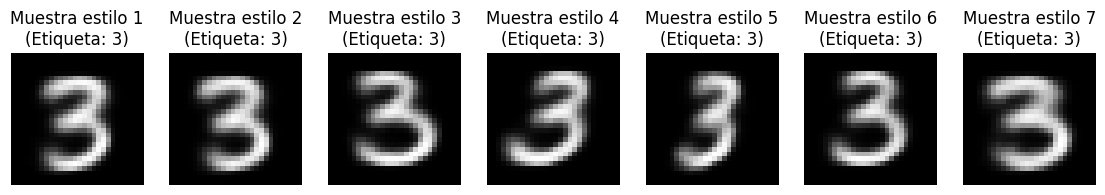

Instrucción: Dibuja diferentes estilos del número 8
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 586ms/step


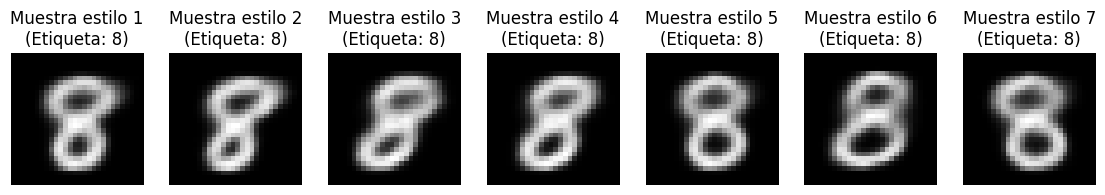

Instrucción: Dibuja diferentes estilos del número 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step


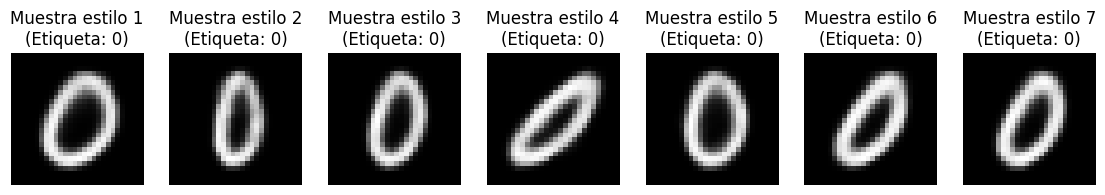

In [13]:
def dibujar_numero(digito_deseado, num_muestras=7):
    """
    Toma un dígito (0-9) y genera iteraciones aleatorias del mismo.
    """
    # 1. Creamos la etiqueta (Condition) repetida para todas las muestras
    condicion_one_hot = keras.utils.to_categorical([digito_deseado] * num_muestras, num_classes=10)
    
    # 2. Generamos puntos puramente aleatorios para el espacio latente
    # Dimensión del espacio latente es 2
    ruido_latente = tf.random.normal(shape=(num_muestras, 2))
    
    # 3. Le pasamos el ruido Y la etiqueta solo al DECODER
    # El decoder ya aprendió a interpretar el ruido como 'estilo' y la etiqueta como 'forma'
    imagenes_imaginadas = decoder_cond.predict([ruido_latente, condicion_one_hot])
    
    # Visualización
    plt.figure(figsize=(14, 2))
    for i in range(num_muestras):
        ax = plt.subplot(1, num_muestras, i + 1)
        plt.imshow(imagenes_imaginadas[i].reshape(28, 28), cmap='gray')
        plt.title(f"Muestra estilo {i+1}\n(Etiqueta: {digito_deseado})")
        plt.axis("off")
    plt.show()

# ¡Vamos a darle órdenes a nuestra red!
print("Instrucción: Dibuja diferentes estilos del número 3")
dibujar_numero(3)

print("Instrucción: Dibuja diferentes estilos del número 8")
dibujar_numero(8)

print("Instrucción: Dibuja diferentes estilos del número 0")
dibujar_numero(0)

### Conclusión Final

Tras completar la implementación y el análisis visual de los modelos avanzados (Autoencoder Convolucional y VAE Condicional), podemos destacar las siguientes lecciones críticas sobre compresión y generación de datos:

1.  **Ejercicio 3 (Autoencoder Convolucional y la Topología 2D):**
    *   **Calidad de Reconstrucción:** Ha quedado visualmente demostrado que las capas convolucionales (`Conv2D` y convoluciones transpuestas) superan por amplio margen a las redes Densas clásicas.
    *   **Preservación Espacial:** Al aplanar las matrices a vectores 1D (como en anteriores ejercicios), el modelo se vuelve "ciego" a la vecindad de los píxeles. Las convoluciones aprovechan estas dependencias locales (bordes y esquinas), logrando comprimir el espacio latente sin sacrificar la nitidez ni inducir la borrosidad típica de una reconstrucción puramente matemática.

2.  **Ejercicio 4 (VAE Condicional o CVAE):**
    *   **Control Determinista del Modelo Generativo:** El VAE tradicional nos permite interpolar y crear, pero sin saber qué dígito surgirá de ese ruido iterado. El CVAE resuelve esto elegantemente condicionando el proceso probabilístico mediante la inyección del *One-Hot Encoding*.
    *   **"Desenredo" de Variables (Disentanglement):** Nuestro modelo aprendió a separar exitosamente la "identidad" de la imagen de su "estilo". Como vimos en los resultados, pudimos usar el *Decoder* para generar variantes del número "3" o "8" a voluntad, donde el muestreo del espacio latente se encargó puramente de la rotación y el trazo de la tinta, pero la etiqueta dictó de forma absoluta qué número delinear.

**Reflexión Final:**
Este notebook resume la transición del aprendizaje representacional simple (compresión dimensional) hacia arquitecturas generativas de vanguardia (VAE). La evolución al condicionamiento (CVAE) marca la frontera directa hacia sistemas más modernos (como modelos de Difusión o Text-to-Image), en los que exigimos a la inteligencia artificial no solo que imagine algo "creíble", sino que imagine exactamente aquello que le parametrizamos.

## 8. Referencias y Recursos

- [TensorFlow Autoencoder Tutorial](https://www.tensorflow.org/tutorials/generative/autoencoder)
- [VAE Tutorial - Keras](https://keras.io/examples/generative/vae/)
- Kingma & Welling (2014). *Auto-Encoding Variational Bayes.*

---

📎 **Notebook anterior:** [08. Redes Generativas (GANs)](./08_gans.ipynb)  
📎 **Notebook siguiente:** [10. Clustering y Reducción de Dimensionalidad](./10_clustering_reduccion_dimensionalidad.ipynb)